## Trabajo Final: Análisis de la Inversión Pública en el Perú

**Grupo 5:** 

* Rodas Cienfuegos, Ulises Alexander. F0558795
* Gamarra Mendoza Milagros Georgina. 20185844
* Linares Herrera, Durga Valentina. F1482478
* María Lesly León Huamán. 20166498


#### 1. Selección del dataset y planteamiento del problema

Para el presente proyecto se ha seleccionado el dataset "Public Investments in Peru", el cual consolida información del Sistema Nacional de Programación Multianual y Gestión de Inversiones del 2020-2024. La relevancia de este conjunto de datos radica en que permite auditar y comprender la distribución territorial y sectorial de los recursos del Estado. Analizar esta información es clave para identificar disparidades regionales, prioridades reales de política pública y posibles ineficiencias (sobrecostos) en la ejecución de proyectos de inversión.

**Link:** [Dataset: Public Investments in Peru](https://www.kaggle.com/datasets/jenifergrategarro/dataset-public-investments-in-peru/data)

**Pregunta de investigación:**
¿Cómo se distribuye el presupuesto y los sobrecostos de la inversión pública peruana a nivel territorial y sectorial, y qué patrones de concentración o ineficiencia financiera se pueden identificar en las obras ejecutadas?

In [ ]:
# 1. Importación de librerías y conexión

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [ ]:
# Subimos un nivel (saldrá de 'analysis' y verá a las otras 3 carpetas hermanas)
sys.path.append(os.path.abspath(".."))

from queries.script_queries import (
    obtener_inversion_por_region,
    analizar_desviacion_sectorial,
    obtener_ranking_regional_top3,
    clasificar_magnitud_proyectos,
    analizar_rentabilidad_social,
    analizar_efecto_callao_atomizacion, 
    analizar_brecha_centralizacion,
    obtener_top_10_proyectos_mas_caros 
)

# Configuramos la conexión a PostgreSQL
load_dotenv() 

DB_USER = "postgres" 
DB_PASSWORD = os.getenv('passles_psql') # Cambiar con la variable del entorno local
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "inversion_publica_db"

cadena_conexion = f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?client_encoding=utf8'
engine = create_engine(cadena_conexion)

print(" Conexión y módulos cargados exitosamente")

 Conexión y módulos cargados exitosamente


#### 2. Concentración regional de la inversión

El primer paso es entender cómo el Estado distribuye el presupuesto en el territorio nacional. A continuación, extraemos el Top 10 de los departamentos con mayor presupuesto asignado a proyectos activos.

C:\Users\Lesly\AppData\Local\Temp\ipykernel_17228\3133369135.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


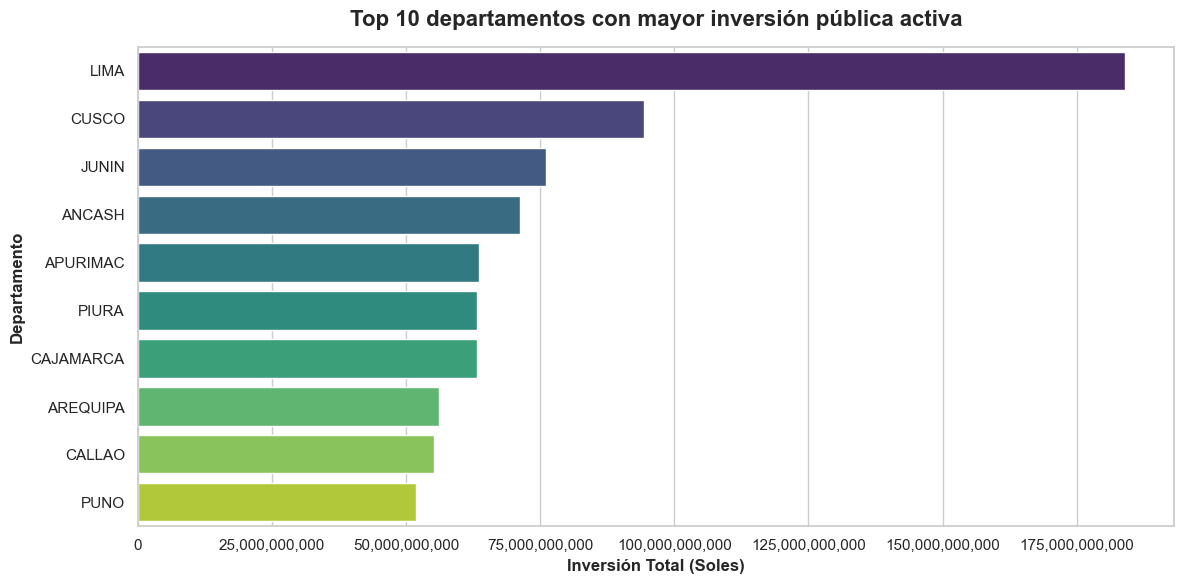

In [ ]:
# 1. Extraemos los datos usando nuestro módulo
df_inversion_regional = obtener_inversion_por_region(engine)
top_10_regiones = df_inversion_regional.head(10)

# 2. Configuramos la visualización
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

barplot = sns.barplot(
    data=top_10_regiones, 
    x='inversion_total', 
    y='departamento', 
    palette='viridis' 
)

plt.title('Top 10 departamentos con mayor inversión pública activa', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Inversión Total (Soles)', fontsize=12, fontweight='bold')
plt.ylabel('Departamento', fontsize=12, fontweight='bold')

# Formato numérico para el eje X (quitar notación científica)
barplot.ticklabel_format(style='plain', axis='x')
barplot.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

Sin embargo, muchas veces un solo proyecto puede significar la mayoría del presupuesto en estos años:

In [33]:
# 1. Extraemos los datos
df_top10 = obtener_top_10_proyectos_mas_caros(engine)

# 2. Le damos un formato visual elegante usando la función "style" de Pandas
tabla_formateada = df_top10.style.format({
    "Costo Total (S/)": "S/ {:,.2f}" # Le pone el símbolo de soles y separadores de miles
}).hide(axis="index").set_properties(**{
    'text-align': 'left',
    'font-size': '12px',
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
])

# 3. Mostramos la tabla
tabla_formateada

Nombre del Proyecto,Sector,Departamento,Costo Total (S/)
"CREACION DEL SERVICIO FERROVIARIO INTERURBANO EN SAN JUAN DE MARCONA – ANDAHUAYLAS, DISTRITO DE MARCONA, PROVINCIA DE NASCA DEL DEPARTAMENTO DE ICA - DISTRITO DE JOSE MARIA ARGUEDAS DE LA PROVINCIA DE ANDAHUAYLAS DEL DEPARTAMENTO DE APURIMAC",TRANSPORTES Y COMUNICACIONES,APURIMAC,"S/ 30,552,699,580.07"
"CREACION DEL SERVICIO DE TRANSITABILIDAD VIAL INTERURBANA EN LA NUEVA CARRETERA CENTRAL ATE – CIENEGUILLA – ANTIOQUÍA - SANTO DOMINGO DE OLLEROS - CUENCA -LANGA – HUAROCHIRI - SAN MATEO - YAULI - EMP. PE-22 , DISTRITO DE YAULI DE LA PROVINCIA DE YAULI DEL DEPARTAMENTO DE JUNIN",TRANSPORTES Y COMUNICACIONES,JUNIN,"S/ 24,528,949,829.00"
"CREACION DEL SERVICIO FERROVIARIO INTERURBANO EN EL FERROCARRIL LIMA – ICA, DISTRITO DE LA TINGUILLA, PROVINCIA DE ICA DEL DEPARTAMENTO DE ICA - DISTRITO DE VILLA EL SALVADOR DE LA PROVINCIA DE LIMA DEL DEPARTAMENTO DE LIMA",TRANSPORTES Y COMUNICACIONES,LIMA,"S/ 24,514,698,856.70"
"CREACION DE LA LINEA 3 DE LA RED BASICA DEL METRO DE LIMA, PROVINCIA DE LIMA, DEPARTAMENTO DE LIMA DISTRITO DE LIMA - PROVINCIA DE LIMA - DEPARTAMENTO DE LIMA",TRANSPORTES Y COMUNICACIONES,LIMA,"S/ 23,569,314,021.37"
"CONSTRUCCION DE LA LINEA 2 Y RAMAL AV. FAUCETT-GAMBETTA DE LA RED BASICA DEL METRO DE LIMA Y CALLAO PROVINCIAS DE LIMA Y CALLAO, DEPARTAMENTO DE LIMA",TRANSPORTES Y COMUNICACIONES,CALLAO,"S/ 17,212,930,870.64"
"CREACION DE LA LINEA 4 DEL METRO DE LIMA Y CALLAO, PROVINCIAS DE LIMA Y CALLAO, DEPARTAMENTO DE LIMA SAN ISIDRO DEL DISTRITO DE SAN ISIDRO - PROVINCIA DE LIMA - DEPARTAMENTO DE LIMA",TRANSPORTES Y COMUNICACIONES,CALLAO,"S/ 12,615,095,387.88"
CONSTRUCCION DEL ANILLO VIAL PERIFÉRICO DE LA CIUDAD DE LIMA Y CALLAO,ECONOMIA Y FINANZAS,CALLAO,"S/ 6,771,889,600.00"
"MEJORAMIENTO Y AMPLIACION DE LOS SERVICIOS DE AGUA POTABLE Y ALCANTARILLADO EN LOS SECTORES DEL 400 AL 425 - DISTRITO DE SAN JUAN DE LURIGANCHO - PROVINCIA DE LIMA - DEPARTAMENTO DE LIMA Y LOS ANEXOS 2, 21, 24 Y MINAS DE PEDREGAL - DISTRITO DE SAN ANTONIO - PROVINCIA DE HUAROCHIRI - DEPARTAMENTO DE LIMA",FONAFE,LIMA,"S/ 6,136,452,982.23"
PROYECTO CHAVIMOCHIC TERCERA ETAPA,GOBIERNOS REGIONALES,LA LIBERTAD,"S/ 3,887,949,069.92"
CREACION DEL SERVICIO DE TRANSITABILIDAD VIAL INTERURBANA EN VIA DE EVITAMIENTO DE CUSCO DISTRITO DE SANTIAGO DE LA PROVINCIA DE CUSCO DEL DEPARTAMENTO DE CUSCO,TRANSPORTES Y COMUNICACIONES,CUSCO,"S/ 3,577,766,469.44"


#### 3. Ineficiencia financiera: Sobrecostos sectoriales 
Para responder a la primera parte de nuestra problemática, evaluamos qué sectores presentan la mayor desviación entre su presupuesto inicial y el costo total final. *(Nota: Esta consulta utiliza JOINs entre la tabla de hechos y la dimensión sectores, además de funciones de agregación como AVG y COUNT).*

C:\Users\Lesly\AppData\Local\Temp\ipykernel_17228\3438802826.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_desviacion.head(10), x='desviacion_promedio_pct', y='nombre_sector', palette='Reds_r')


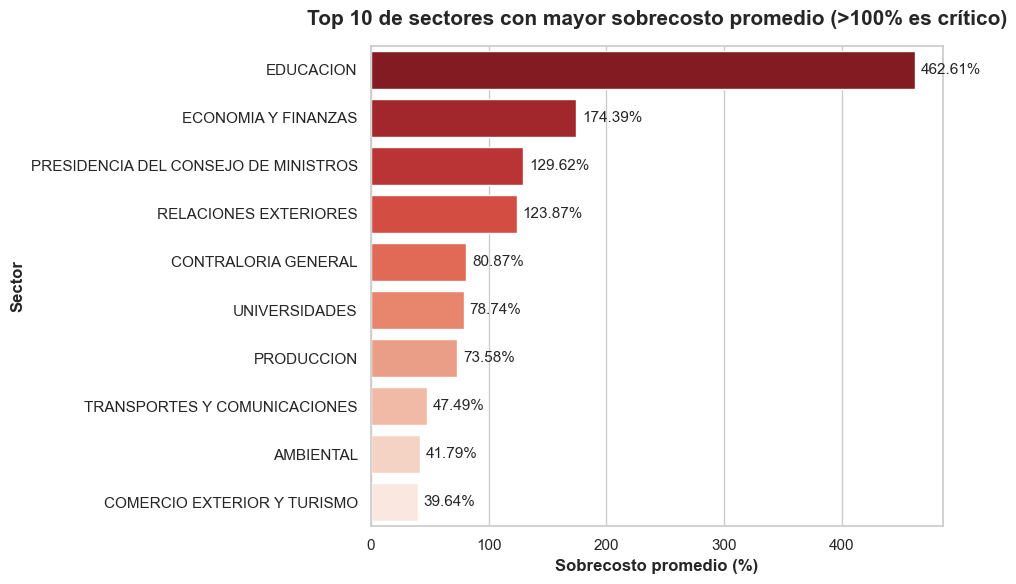

nombre_sector,num_proyectos,desviacion_promedio_pct
EDUCACION,"2,919",462.61%
ECONOMIA Y FINANZAS,79,174.39%
PRESIDENCIA DEL CONSEJO DE MINISTROS,161,129.62%
RELACIONES EXTERIORES,14,123.87%
CONTRALORIA GENERAL,6,80.87%
UNIVERSIDADES,38,78.74%
PRODUCCION,247,73.58%
TRANSPORTES Y COMUNICACIONES,"1,480",47.49%
AMBIENTAL,122,41.79%
COMERCIO EXTERIOR Y TURISMO,83,39.64%


In [29]:
# Extraemos los datos de la base de datos
df_desviacion = analizar_desviacion_sectorial(engine)

# Gráfico de barras para sobrecostos
plt.figure(figsize=(10, 6))
sns.barplot(data=df_desviacion.head(10), x='desviacion_promedio_pct', y='nombre_sector', palette='Reds_r')
plt.title('Top 10 de sectores con mayor sobrecosto promedio (>100% es crítico)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Sobrecosto promedio (%)', fontsize=12, fontweight='bold')
plt.ylabel('Sector', fontsize=12, fontweight='bold')

# Añadimos etiquetas a las barras
for index, value in enumerate(df_desviacion.head(10)['desviacion_promedio_pct']):
    plt.text(value + 5, index, f'{value}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()

# Mostramos la tabla con formato
df_desviacion.head(10).style.format({
    "num_proyectos": "{:,}",
    "desviacion_promedio_pct": "{:,.2f}%" 
}).hide(axis="index").set_properties(**{
    'text-align': 'center', 'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#FF5722'), ('color', 'white')]}
])

Ese 462.61% de desviación en el sector Educación no es un simple error de cálculo contable; es el reflejo de un sistema colapsado. Que un proyecto termine costando casi cinco veces y media su valor original nos habla de tres fenómenos graves:

* **Expedientes técnicos deficientes:** Se aprueban obras en papel sin estudios de suelo reales o sin prever la logística en zonas rurales, lo que obliga a inyectar más y más dinero (adendas) durante la ejecución.

* **Obras paralizadas y destrabadas:** Muchos colegios quedan a medio construir por disputas legales con contratistas. Años después, cuando el Estado intenta retomar la obra, los materiales están arruinados y los costos se han disparado por la inflación.

* **El costo social:** Mientras el presupuesto es absorbido por estas ineficiencias, miles de estudiantes siguen estudiando en módulos prefabricados. El sobrecosto en Educación es, literalmente, dinero que ya no se puede usar para construir el siguiente colegio o mejorar salarios docentes.

Más información en: [Link](https://gestion.pe/economia/ahora-casi-14-mil-obras-publicas-en-peru-son-mas-caras-que-lo-previsto-al-inicio-noticia/)

#### 4. Focalización de la inversión: megaproyectos vs. obras menores

La magnitud financiera de los proyectos nos permite entender la estrategia de desarrollo territorial del Estado. A través de una agregación condicional (**CASE WHEN**) en SQL, clasificamos el portafolio de proyectos según su magnitud financiera (menores a S/ 1 millón, entre S/ 1M y S/ 10M, y megaproyectos mayores a S/ 10M).

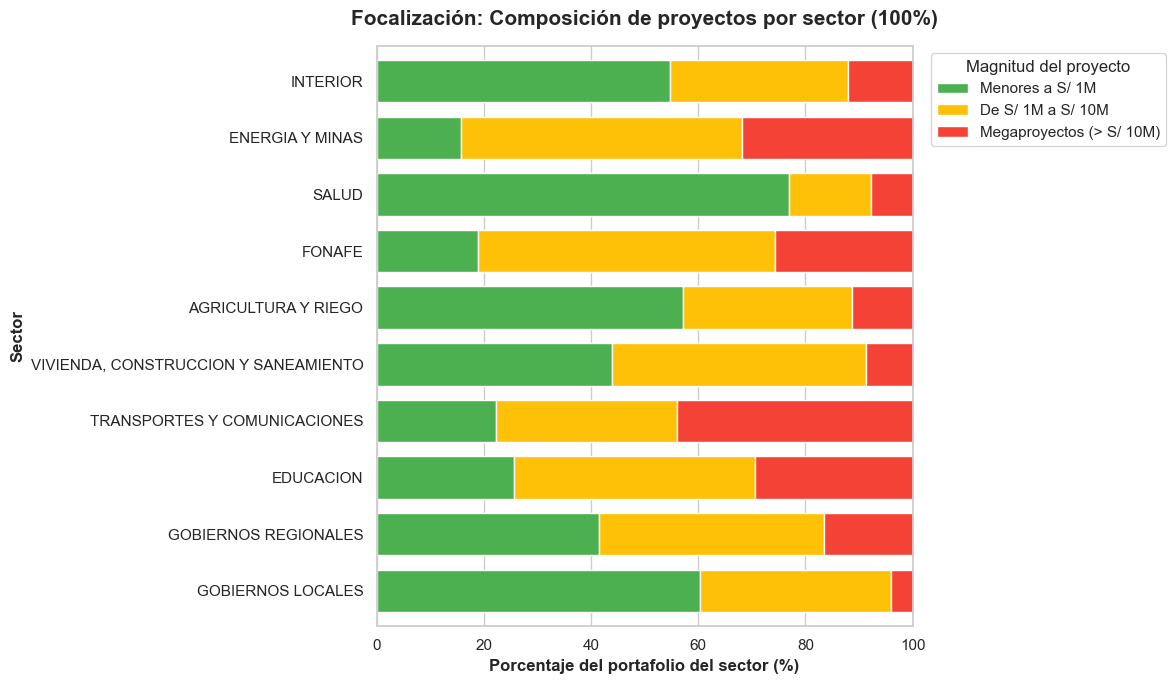


Respado en valores absolutos (Cantidad real de proyectos):


,proyectos_menores_1m,proyectos_1m_a_10m,megaproyectos_mas_10m
nombre_sector,,,
GOBIERNOS LOCALES,"129,364","76,119","8,673"
GOBIERNOS REGIONALES,"9,094","9,229","3,632"
EDUCACION,746,"1,313",860
TRANSPORTES Y COMUNICACIONES,329,501,650
"VIVIENDA, CONSTRUCCION Y SANEAMIENTO","1,449","1,567",286
AGRICULTURA Y RIEGO,"1,331",738,262
FONAFE,162,477,220
SALUD,"1,603",316,162
ENERGIA Y MINAS,68,227,138


In [ ]:
# 1. Extraemos los datos
df_magnitud = clasificar_magnitud_proyectos(engine)

# 2. Tomamos el Top 10 y lo preparamos
top_10_magnitud = df_magnitud.head(10).copy()
top_10_magnitud.set_index('nombre_sector', inplace=True)

# 3. Sumamos el total de proyectos por cada sector
totales_por_sector = top_10_magnitud.sum(axis=1)

# 4. Dividimos cada columna entre el total del sector y multiplicamos por 100
top_10_pct = top_10_magnitud.div(totales_por_sector, axis=0) * 100

# Gráficamos
colores = ['#4CAF50', '#FFC107', '#F44336'] # Verde, Amarillo, Rojo
etiquetas_leyenda = ['Menores a S/ 1M', 'De S/ 1M a S/ 10M', 'Megaproyectos (> S/ 10M)']

ax = top_10_pct.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 7), 
    color=colores,
    width=0.75,
    edgecolor='white' 
)

plt.title('Focalización: Composición de proyectos por sector (100%)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Porcentaje del portafolio del sector (%)', fontsize=12, fontweight='bold')
plt.ylabel('Sector', fontsize=12, fontweight='bold')
plt.xlim(0, 100) 

plt.legend(etiquetas_leyenda, title='Magnitud del proyecto', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Mostramos la tabla original en valores absolutos como respaldo
print("\nRespado en valores absolutos (Cantidad real de proyectos):")
display(top_10_magnitud.style.format("{:,}").set_properties(**{
    'text-align': 'center', 'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', "#24BC9D65"), ('color', 'white')]}
]))

Este gráfico revela lo que en gestión pública llamamos la **"hiper-atomización del gasto"**.

* **Barra verde / Barra amarilla en Gobiernos locales**: Tienen decenas de miles de proyectos, pero la inmensa mayoría son obras menores a 1 millón o menores a 10 millones.

* **Lógica política vs. Lógica de desarrollo:** Muchos alcaldes prefieren hacer 50 parquecitos, losas deportivas, veredas o refacciones pequeñas (la barra verde) porque se construyen rápido y generan visibilidad política inmediata (clientelismo o rentabilidad electoral). Sin embargo, estas micro-obras rara vez cambian la aguja del desarrollo estructural.

* **Falta de capacidad técnica:** La descentralización le dio dinero a los municipios, pero no les dio ingenieros ni proyectistas de alto nivel. Por eso casi no hacen megaproyectos (la barra roja es mínima en proporción). El Estado está gastando miles de millones "a goteo", en lugar de consolidar grandes corredores económicos, hospitales regionales o redes de agua integrales.

Más información: [Informe de Comex Perú](https://www.comexperu.org.pe/articulo/gestion-municipal-en-2025-el-967-requiere-asistencia-tecnica-o-capacitacion); [Informe de La República](https://especial.larepublica.pe/metro-cuadrado/vivienda-y-construccion/2026/02/03/municipios-con-millones-sin-gastar-por-que-tantas-obras-publicas-siguen-paralizadas-en-el-peru-265410)

#### 5. El "Efecto Callao" vs.  la atomización del gasto
Para comprender el riesgo y la estrategia financiera por región, analizamos la dispersión del portafolio. El objetivo es contrastar la **Cantidad de proyectos** (eje X) frente al **Costo promedio por proyecto** (eje Y). 

Al cruzar la cantidad de proyectos con el costo promedio por obra, emergen dos modelos opuestos de gestión pública: la alta atomización (miles de obras de bajo presupuesto, como en Áncash) frente a la concentración en megaproyectos (pocas obras de altísimo presupuesto, como el "Efecto Callao"). 

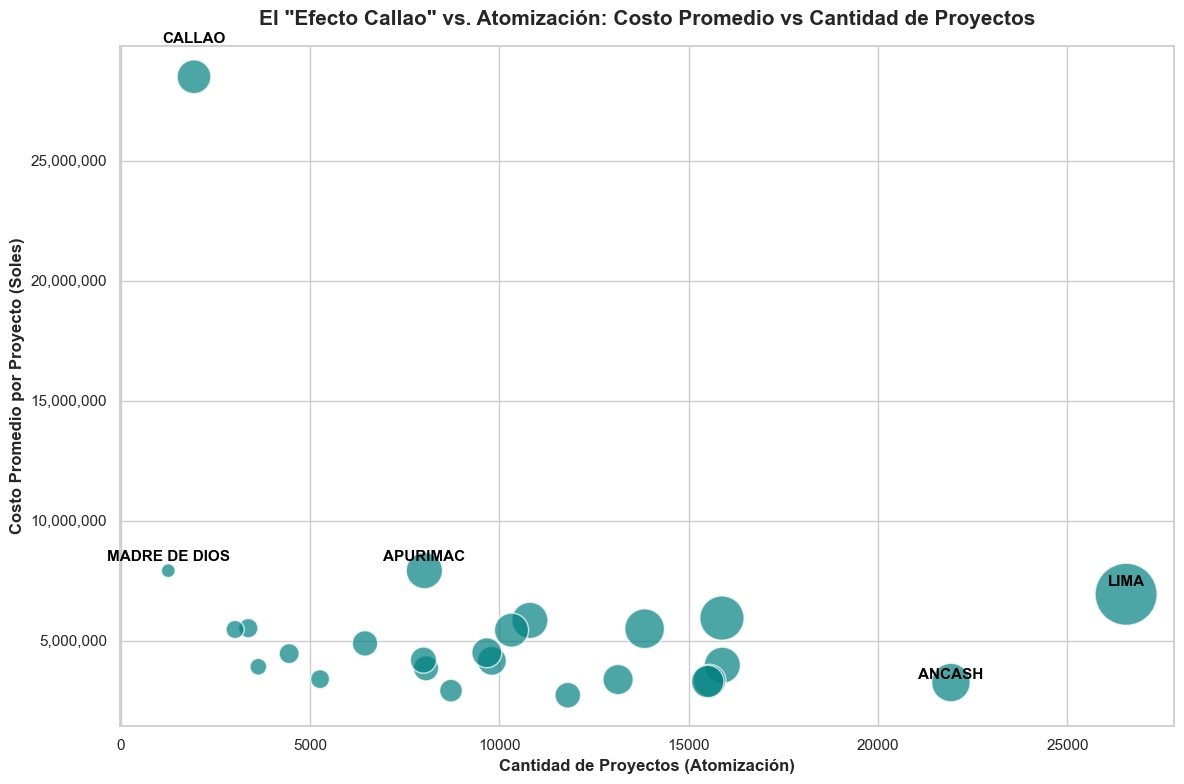

departamento,cantidad_proyectos,costo_promedio,inversion_total
LIMA,"26,551","S/ 6,928,921.25","S/ 183,969,788,120.10"
ANCASH,"21,925","S/ 3,251,055.33","S/ 71,279,388,176.95"
APURIMAC,"8,020","S/ 7,916,656.44","S/ 63,491,584,632.77"
CALLAO,"1,935","S/ 28,489,771.49","S/ 55,127,707,834.29"
MADRE DE DIOS,"1,256","S/ 7,912,672.42","S/ 9,938,316,564.73"


In [40]:
df_dispersion = analizar_efecto_callao_atomizacion(engine)

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=df_dispersion, x='cantidad_proyectos', y='costo_promedio',
    size='inversion_total', sizes=(100, 2000), alpha=0.7, color='teal', legend=False
)

regiones_clave = ['CALLAO', 'ANCASH', 'LIMA', 'MADRE DE DIOS', 'APURIMAC']
for i in range(df_dispersion.shape[0]):
    reg = df_dispersion['departamento'].iloc[i]
    x_val = df_dispersion['cantidad_proyectos'].iloc[i]
    y_val = df_dispersion['costo_promedio'].iloc[i]
    if reg in regiones_clave:
        plt.text(x_val, y_val + (y_val*0.05), reg, horizontalalignment='center', size='11', color='black', weight='bold')

plt.title('El "Efecto Callao" vs. Atomización: Costo Promedio vs Cantidad de Proyectos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Proyectos (Atomización)', fontsize=12, fontweight='bold')
plt.ylabel('Costo Promedio por Proyecto (Soles)', fontsize=12, fontweight='bold')

scatter.ticklabel_format(style='plain', axis='y')
scatter.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()
plt.show()

df_casos = df_dispersion[df_dispersion['departamento'].str.upper().isin(regiones_clave)].copy()
display(df_casos.style.format({
    "cantidad_proyectos": "{:,}",
    "costo_promedio": "S/ {:,.2f}",
    "inversion_total": "S/ {:,.2f}"
}).hide(axis="index").set_properties(**{
    'text-align': 'center', 'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#009688'), ('color', 'white')]}
]))

#### 6. Análisis de casos extremos: El Top 3 Regional
Para profundizar en la disparidad territorial y entender cómo se distribuye el riesgo financiero dentro de cada departamento, implementamos funciones de ventana (RANK y OVER) junto con CTEs en SQL. Esto nos permitió extraer y rankear los proyectos más costosos por cada región.

Como se observa en la siguiente tabla para los casos de Áncash y Ayacucho, el *Top 3* de inversión está monopolizado absolutamente por megaproyectos de infraestructura vial (carreteras que superan los 1,100 millones de soles). 

In [ ]:
# Acortamos un poco el nombre del proyecto para que la tabla no se desborde en la pantalla
df_ranking['nombre_proyecto_corto'] = df_ranking['nombre_proyecto'].apply(lambda x: x[:80] + '...' if len(x) > 80 else x)

tabla_top_regional = df_ranking[['departamento', 'nombre_proyecto_corto', 'costo_total', 'puesto_regional']].style.format({
    "costo_total": "{:,.2f}" # Mantiene el formato numérico con comas
}).hide(axis="index").set_properties(**{
    'text-align': 'left',
    'border': '1px solid black',
    'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1976D2'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
])

display(tabla_top_regional)

departamento,nombre_proyecto_corto,costo_total,puesto_regional
AMAZONAS,MEJORAMIENTO DE LA CARRETERA PE - 5NC Y PE-5NE PUENTE WAWICO - NUEVO SIASME DIST...,"656,254,436.90",1
AMAZONAS,SEGUNDA FASE DEL PROGRAMA DE APOYO A LA REFORMA DEL SECTOR SALUD - PARSALUD II,"479,794,638.00",2
AMAZONAS,"MEJORAMIENTO DE LA CARRETERA PE-5NC, NUEVO SIASME - SARAMIRIZA LA PROVINCIA DE C...","455,119,797.55",3
ANCASH,"MEJORAMIENTO DE LA CARRETERA HUANUCO-CONOCOCHA, SECTOR: HUANUCO-LA UNION-HUALLAN...","1,596,459,741.78",1
ANCASH,CONSTRUCCION DE CRUCE A DESNIVEL Y VIAS DE ACCESO; EN EL(LA) VIA EVITAMIENTO DE ...,"1,479,632,983.95",2
ANCASH,MEJORAMIENTO Y AMPLIACION DE LOS SERVICIOS DE AGUA POTABLE Y ALCANTARILLADO EN L...,"1,109,438,147.43",3
APURIMAC,CREACION DEL SERVICIO FERROVIARIO INTERURBANO EN SAN JUAN DE MARCONA – ANDAHUAYL...,"30,552,699,580.07",1
APURIMAC,REHABILITACION Y MEJORAMIENTO DE LA CARRETERA AYACUCHO - ABANCAY,"1,917,263,482.63",2
APURIMAC,MEJORAMIENTO DE LA CAPACIDAD DIAGNOSTICA Y RESOLUTIVA DE LOS SERVICIOS DE ATENCI...,"815,516,966.06",3
AREQUIPA,MAJES SIGUAS - II ETAPA,"2,448,642,649.88",1


#### 7. Conclusiones

**1. Crisis de planificación y sobrecostos:** Existe una deficiencia estructural en la elaboración de expedientes técnicos, especialmente en sectores críticos como Educación. El hallazgo de un sobrecosto promedio del 462.6% en este sector revela que el Estado no solo gasta mal, sino que es incapaz de prever contingencias, lo que deriva en una pérdida de recursos que podrían destinarse a cerrar otras brechas sociales.

**2. La trampa de la atomización frente a la concentración:** El análisis del "Efecto Callao" vs. la realidad de Áncash demuestra una gestión territorial cuestionable. Mientras algunas regiones fragmentan su presupuesto en miles de micro-obras de bajo impacto, otras concentran su riqueza en un solo megaproyecto, generando una vulnerabilidad financiera extrema donde el desarrollo regional depende del éxito o fracaso de una única obra.

**3. Desconexión en la focalización:** El análisis de magnitud financiera y el Top 3 de proyectos regionales evidencia que el Estado prioriza casi de manera exclusiva la infraestructura pesada (Transporte y carreteras) para la asignación de sus megaproyectos. En contraste, sectores vitales para el desarrollo del capital humano, como Salud y Educación, sufren una severa atomización (abundancia de micro-obras menores a S/ 1 millón). Esto demuestra empíricamente que la inversión pública actual está más orientada a la ejecución logística que al cierre estratégico y de gran impacto de las brechas sociales.